In [4]:
import pandas as pd
import sqlalchemy as sa
import urllib
from sqlalchemy import create_engine
from sqlalchemy import text
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
df = pd.read_csv('C:/Users/bryan/OneDrive/Desktop/Python_Projects/Chocolate_Sales/Raw_data/Chocolate_Sales.csv')

In [5]:
df.insert(0, 'order_id', range(1, 1 + len(df))) ##insert index primary key
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True) ## Convert to datetime indicating format
df['sales_month'] = df['Date'].dt.month # extract month from datetime
df['sales_year'] = df['Date'].dt.year # extract year from datetime
df['Amount'] = df['Amount'].str.replace(r'[$,]', '', regex=True) # takeout '$' in string to be able to convert datatype
df['Amount'] = df['Amount'].astype(float) 
df['Amount'] = df['Amount'].astype(int)# data conversion to int
df['price_per_box'] = df['Amount']/df['Boxes Shipped'].astype(int) # calculate price per box



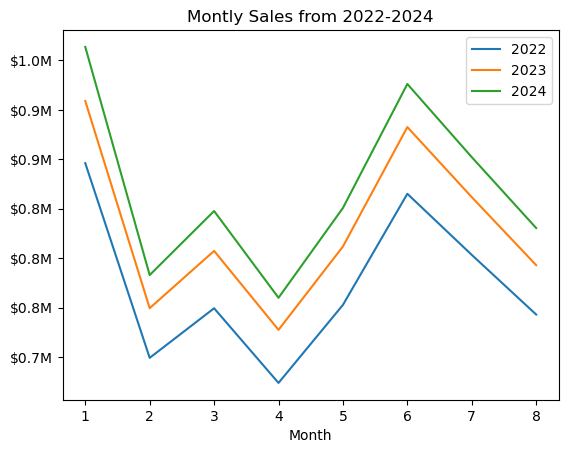

In [6]:
years = [2022, 2023, 2024]
plots = {}
ax=plt.gca()
for year in years:
    # 1. Filter and Copy
    temp_df = df[df['sales_year'] == year].copy()
    
    # 2. Sort and Group (Sorting is usually better done on the grouped result)
    plots[year] = temp_df.groupby('sales_month')['Amount'].sum().sort_index()

# Now you can access them easily:
# plots[2024] gives you the 2024 Series

for year, data in plots.items():
    data.plot(label=str(year))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y/1000000:.1f}M'))
plt.legend()
plt.title('Montly Sales from 2022-2024')
plt.ylabel('')
plt.xlabel('Month')
plt.show()

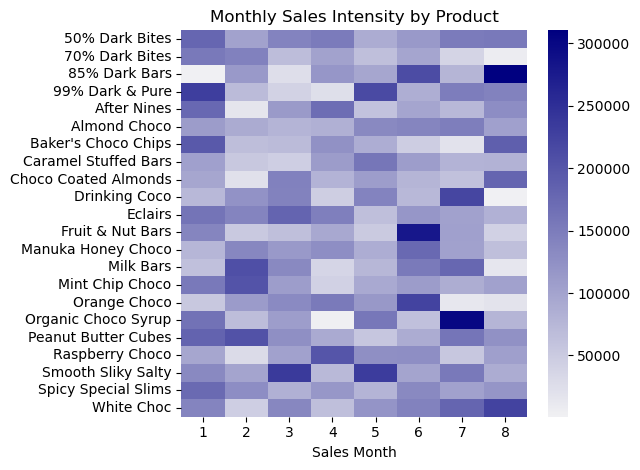

In [7]:
# Create the pivot table
product_pivot = df.pivot_table(
    index='Product',      # What you want on the LEFT (rows)
    columns='sales_month',# What you want on the TOP (columns)
    values='Amount',      # The numbers you are calculating
    aggfunc='sum'         # How to handle the math (sum, mean, count, etc.)
)

# Fill any empty spots (months with zero sales) with 0
product_pivot = product_pivot.fillna(0)
product_pivot
sns.heatmap(product_pivot, cmap=sns.light_palette("navy", as_cmap=True))
plt.title('Monthly Sales Intensity by Product')
plt.ylabel('')
plt.xlabel('Sales Month')
plt.tight_layout()
plt.show()

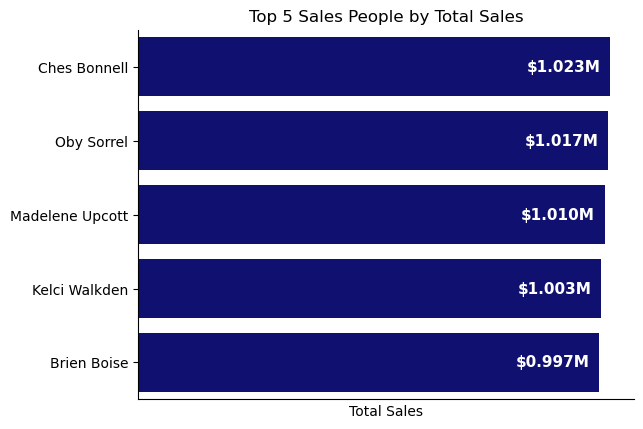

In [8]:
from matplotlib.ticker import FuncFormatter
df_sales_person = df.groupby('Sales Person')[['Amount']].agg(
total_sold = ('Amount', 'sum'))
df_sales_person_plot = df_sales_person.sort_values(by='total_sold', ascending=False).head(5)
sns.barplot(data=df_sales_person_plot, x='total_sold', y='Sales Person', color='navy')
ax=plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000000:.1f}M'))
formatted_labels = [f'${val/1000000:.3f}M' for val in df_sales_person_plot['total_sold']]
sns.despine()
# Apply the labels to the bar chart
ax.bar_label(ax.containers[0], labels=formatted_labels, 
             label_type='edge', padding=-60, 
             color='white', fontweight='bold', fontsize=11)
plt.title('Top 5 Sales People by Total Sales')
plt.ylabel('')
plt.xlabel('Total Sales')
ax.set_xticklabels([])
ax.set_xticks([]) # Removes the X-axis entirely for a cleaner look
plt.show()


C:\Users\bryan\AppData\Local\Temp\ipykernel_19924\4282101643.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(df_plot['Product'], fontweight='bold', fontsize=10)


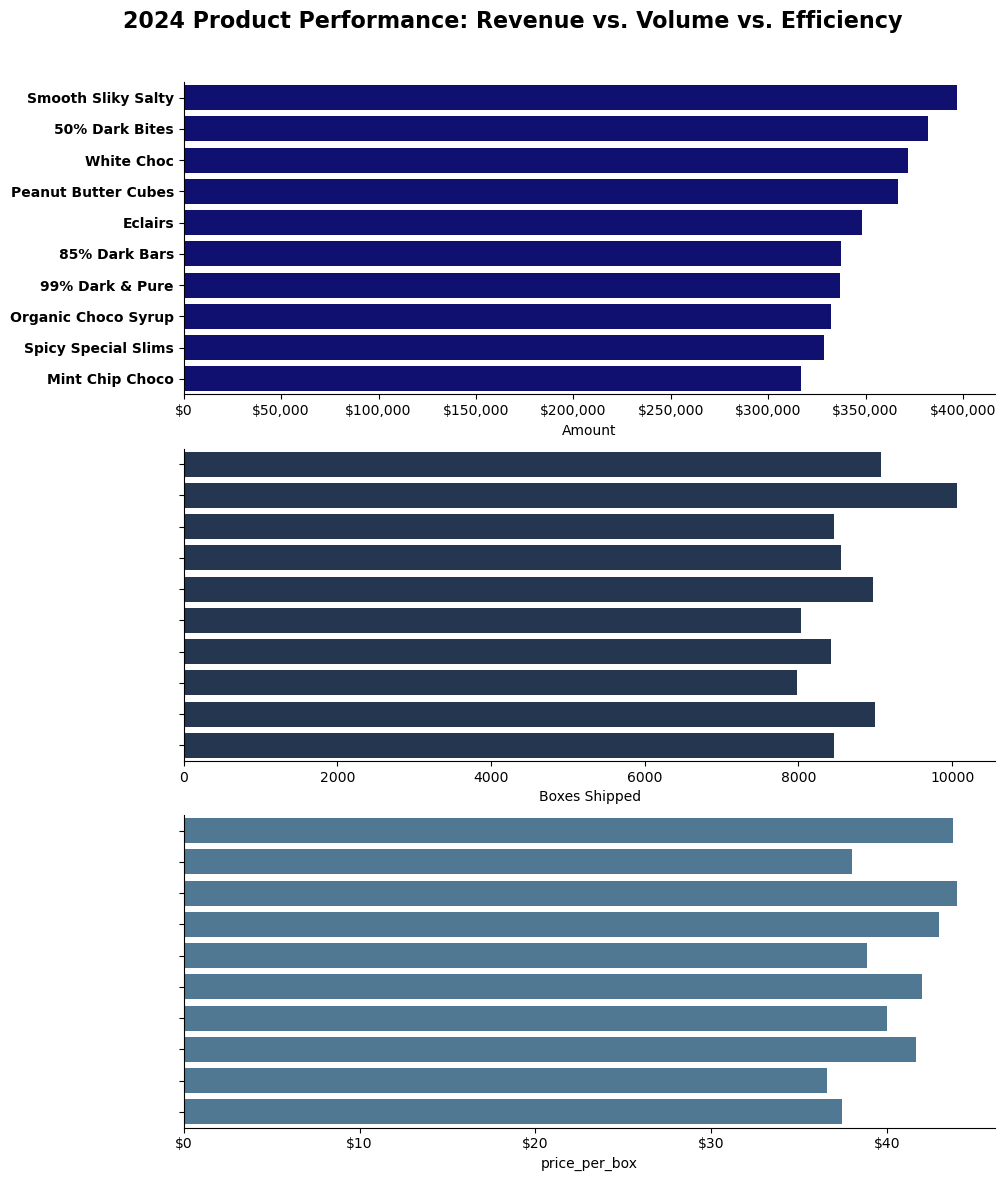

In [9]:
import matplotlib.ticker as mtick

# 1. Data Preparation
# Filter for 2024, group by Product, and sum metrics
df_plot = (df[df['sales_year'] == 2024]
           .groupby('Product')[['Amount', 'Boxes Shipped']]
           .agg('sum')
           .sort_values(by='Amount', ascending=False)
           .head(10)
           .reset_index())

# Calculate the efficiency metric
df_plot['price_per_box'] = df_plot['Amount'] / df_plot['Boxes Shipped']

# 2. Setup the Figure
# sharey=True ensures all bars align perfectly on the left
fig, ax = plt.subplots(3, 1, figsize=(10, 12), sharey=True)

# 3. Plotting
# Using different shades of blue to distinguish the different metrics
sns.barplot(data=df_plot, x='Amount', y='Product', ax=ax[0], color='navy')
sns.barplot(data=df_plot, x='Boxes Shipped', y='Product', ax=ax[1], color='#1d3557')
sns.barplot(data=df_plot, x='price_per_box', y='Product', ax=ax[2], color='#457b9d')

# 4. The "Hammer" Fix for Y-Axis Labels
# sharey=True likes to hide these; we are forcing them back on for the top plot only
plt.setp(ax[0].get_yticklabels(), visible=True)
ax[0].tick_params(labelleft=True)

# 5. Clean up and Formatting
for i, a in enumerate(ax):
    a.set_ylabel('')  # Remove "Product" label from the side
    sns.despine(ax=a)  # Clean aesthetic
    if i > 0:
        a.tick_params(labelleft=False) # Hide names for bottom two

# Currency formatting for Amount and Price per Box
fmt = mtick.StrMethodFormatter('${x:,.0f}')
ax[0].xaxis.set_major_formatter(fmt)
ax[2].xaxis.set_major_formatter(fmt)

# 6. Final Polish
plt.tight_layout()
ax[0].set_yticklabels(df_plot['Product'], fontweight='bold', fontsize=10)
fig.suptitle('2024 Product Performance: Revenue vs. Volume vs. Efficiency', fontsize=16, fontweight='bold', y=0.98)
plt.subplots_adjust(top=0.92) # Make room for the title
plt.show()

Text(0.5, 0, 'Amount Sold')

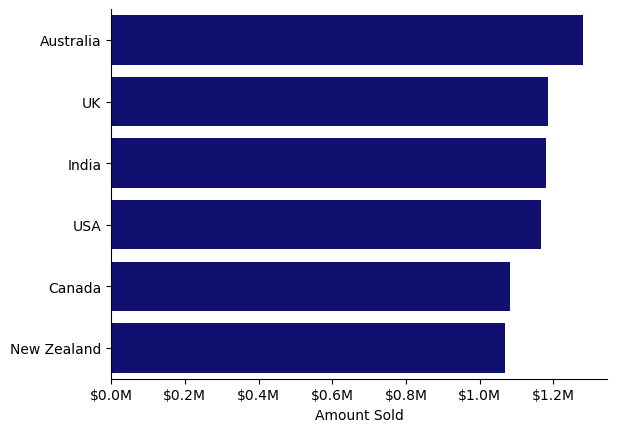

In [10]:
ax=plt.gca()
df_top_country = df[df['sales_year'] == 2024].groupby('Country')['Amount'].sum().reset_index()
df_top_country_plot = df_top_country.sort_values(by='Amount', ascending=False).head(10)
sns.barplot(data=df_top_country_plot, x='Amount', y='Country', color='navy')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000000:.1f}M'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Amount Sold (USD)')
plt.ylabel('')
plt.xlabel('Amount Sold')


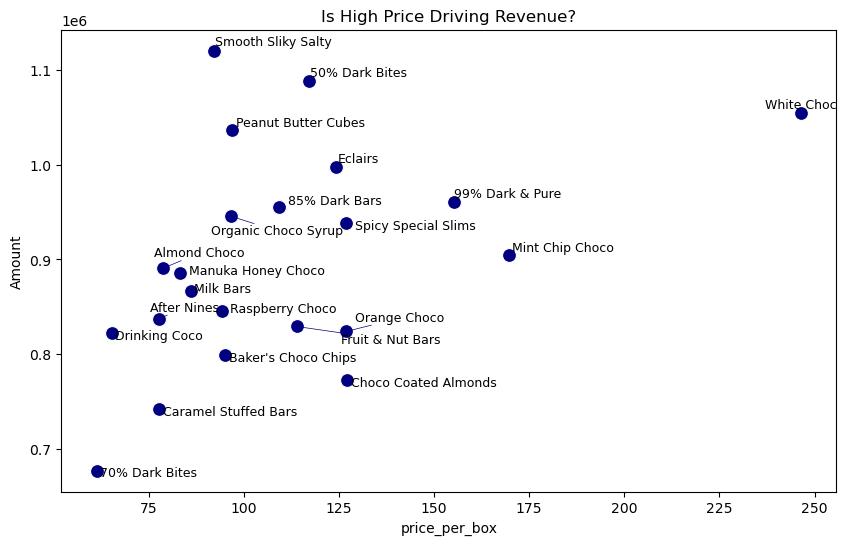

In [11]:
# Grouping to see total performance per price point
df_product_stats = df.groupby('Product').agg({
    'Amount': 'sum',
    'price_per_box': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_product_stats, x='price_per_box', y='Amount', s=100, color='navy')
import adjustText
texts = []
for i in range(df_product_stats.shape[0]):
    # We store the text object in the list instead of just plotting it
    texts.append(plt.text(df_product_stats.price_per_box[i], 
                          df_product_stats.Amount[i], 
                          df_product_stats.Product[i], 
                          fontsize=9))

# 2. Call the FUNCTION inside the module (adjustText.adjust_text)
# Note the underscore in the function name!
adjustText.adjust_text(texts, arrowprops=dict(arrowstyle='->', color='navy', lw=0.5))
plt.title('Is High Price Driving Revenue?')
plt.show()